# Import Packages

In [155]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install geopandas
# !pip install geoalchemy2
# !pip install sqlalchemy

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from geoalchemy2 import Geometry, WKTElement
import matplotlib.pyplot as plt
import os
import glob

import requests
from bs4 import BeautifulSoup
import html5lib

from sqlalchemy import create_engine
import psycopg2
import psycopg2.extras
import json

import shapely
import seaborn as sns

# Set up connection to SQL Server

In [156]:
# !pip install psycopg2
# !pip install psycopg2-binary --user
# !pip install psycopg[binary]

credentials = "/Users/apple/Desktop/Data2901/Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    with open(credential_filepath) as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict['user']
        port       = db_conn_dict['port']
        try:
            db = create_engine(f'postgresql+psycopg2://{db_user}:{db_pw}@{host}:{port}/{default_db}', echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db,conn

def query(conn, sqlcmd, args=None, df=True):
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(text(sqlcmd), args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result

In [157]:
db, conn = pgconnect(credentials)

Connected successfully.


In [158]:
query(conn, "select PostGIS_Version()")

,postgis_version
0,3.4 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


# 1. import all the data

In [5]:
# get all the files in csv
path = os.getcwd() 
csv_files = glob.glob(os.path.join(path, "Data/*.csv")) 

print(csv_files)

# create empty list
dataframes_list = []
 
# append datasets into the list
for i in csv_files:
    temp_df = pd.read_csv(i)
    dataframes_list.append(temp_df)

df_income = dataframes_list[0]
df_pop = dataframes_list[1]
df_pol = dataframes_list[2]
df_business = dataframes_list[3]
print("Income: ",df_income.shape,'; ',df_income.columns)
print('Population: ',df_pop.shape,'; ',df_pop.columns)
print('Polling: ',df_pol.shape,'; ',df_pol.columns)
print('Business: ',df_business.shape,'; ',df_business.columns)

['/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Income.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Population.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/PollingPlaces2019.csv', '/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Businesses.csv']
Income:  (642, 6) ;  Index(['sa2_code21', 'sa2_name', 'earners', 'median_age', 'median_income',
       'mean_income'],
      dtype='object')
Population:  (373, 21) ;  Index(['sa2_code', 'sa2_name', '0-4_people', '5-9_people', '10-14_people',
       '15-19_people', '20-24_people', '25-29_people', '30-34_people',
       '35-39_people', '40-44_people', '45-49_people', '50-54_people',
       '55-59_people', '60-64_people', '65-69_people', '70-74_people',
       '75-79_people', '80-84_people', '85-and-over_people', 'total_people'],
      dtype='object')
Polling:  (2930, 17) ;  Index(['FID', 'state', 'division_id', 'division_name', 'polling_place_id',
       'polling_pl

In [6]:
df_income.head()

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467,51,46640,68904
1,101021008,Karabar,5103,42,65564,69672
2,101021009,Queanbeyan,7028,39,63528,69174
3,101021010,Queanbeyan - East,3398,39,66148,74162
4,101021012,Queanbeyan West - Jerrabomberra,8422,44,78630,91981


In [7]:
df_pop.head()

,sa2_code,sa2_name,0-4_people,5-9_people,10-14_people,15-19_people,20-24_people,25-29_people,30-34_people,35-39_people,...,45-49_people,50-54_people,55-59_people,60-64_people,65-69_people,70-74_people,75-79_people,80-84_people,85-and-over_people,total_people
0,102011028,Avoca Beach - Copacabana,424,522,623,552,386,222,306,416,...,572,602,570,520,464,369,226,142,70,7530
1,102011029,Box Head - MacMasters Beach,511,666,702,592,461,347,420,535,...,749,749,794,895,863,925,603,331,264,11052
2,102011030,Calga - Kulnura,200,225,258,278,274,227,214,286,...,325,436,422,397,327,264,190,100,75,4748
3,102011031,Erina - Green Point,683,804,880,838,661,502,587,757,...,859,882,901,930,917,1065,976,773,1028,14803
4,102011032,Gosford - Springfield,1164,1044,1084,1072,1499,1864,1750,1520,...,1330,1241,1377,1285,1166,949,664,476,537,21346


In [8]:
df_pol.tail()
df_pol['the_geom']

0                                   NaN
1                                   NaN
2                                   NaN
3                                   NaN
4                                   NaN
                     ...               
2925           POINT (-34.5642 150.858)
2926    POINT (-34.5508228 150.8597546)
2927           POINT (-34.4409 150.424)
2928           POINT (-34.5316 150.866)
2929                                NaN
Name: the_geom, Length: 2930, dtype: object

In [9]:
df_business.head()

,industry_code,industry_name,sa2_code,sa2_name,0_to_50k_businesses,50k_to_200k_businesses,200k_to_2m_businesses,2m_to_5m_businesses,5m_to_10m_businesses,10m_or_more_businesses,total_businesses
0,A,"Agriculture, Forestry and Fishing",101021007,Braidwood,136,92,63,4,0,0,296
1,A,"Agriculture, Forestry and Fishing",101021008,Karabar,6,3,0,0,0,0,9
2,A,"Agriculture, Forestry and Fishing",101021009,Queanbeyan,6,4,3,0,0,3,15
3,A,"Agriculture, Forestry and Fishing",101021010,Queanbeyan - East,0,3,0,0,0,0,3
4,A,"Agriculture, Forestry and Fishing",101021012,Queanbeyan West - Jerrabomberra,7,4,5,0,0,0,16


## import txt files

In [10]:
# import txt file
# path = os.getcwd() 
txt_files = glob.glob(os.path.join(path, "*/*.txt")) 
print(txt_files[0])
i = txt_files[0]
df_stops = pd.read_csv(i)
print(df_stops.shape)
print(df_stops.columns)
df_stops.tail()

/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/Stops.txt
(114718, 9)
Index(['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon',
       'location_type', 'parent_station', 'wheelchair_boarding',
       'platform_code'],
      dtype='object')


,stop_id,stop_code,stop_name,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,platform_code
114713,212753,212753.0,"Sydney Olympic Park Wharf, Side B",-33.822016,151.078797,NaN,21271,1,B
114714,2137185,2137185.0,"Cabarita Wharf, Side A",-33.840669,151.116926,NaN,21371,1,1A
114715,2137186,2137186.0,"Cabarita Wharf, Side B",-33.840769,151.116899,NaN,21371,1,1B
114716,21501,21501.0,Parramatta Wharf,-33.813904,151.010577,NaN,2150112,1,NaN
114717,2150112,NaN,Parramatta Wharf,-33.813952,151.010482,1.0,NaN,1,NaN


## read the shp file from catchments

In [83]:
# get the shp files
print(path)
shp_files = glob.glob(os.path.join(path, "Data/*/*.shp")) 

# create empty list
dataframes_list_shp = []
 
# append datasets into the list
for i in shp_files:
    print(i)
    temp_df = gpd.read_file(i, crs="EPSG:4326")
    dataframes_list_shp.append(temp_df)

df_catch_f = dataframes_list_shp[1]
df_catch_s = dataframes_list_shp[0]
df_catch_p = dataframes_list_shp[2]
df_sa2 = dataframes_list_shp[3]
print("catchment future: ",df_catch_f.shape,'; ',df_catch_f.columns)
print('catchment secondary: ',df_catch_s.shape,'; ',df_catch_s.columns)
print('catchment primary: ',df_catch_p.shape,'; ',df_catch_p.columns)
print('sa2: ',df_sa2.shape,'; ',df_sa2.columns)

df_catch_f.head()

/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1
/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/catchments/catchments_secondary.shp
/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/catchments/catchments_future.shp
/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/catchments/catchments_primary.shp
/Users/apple/Desktop/Data2901/Assignment/DATA2901--2024S1/Data/SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp
catchment future:  (30, 18) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'geometry'],
      dtype='object')
catchment secondary:  (436, 19) ;  Index(['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry'],
      dtype='object')

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,geometry
0,8416,HIGH_COED,Ku-ring-gai HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.19849 -33.53990, 151.19945 -33.5..."
1,8161,HIGH_BOYS,Randwick BHS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.27152 -33.91402, 151.27152 -33.9..."
2,8539,HIGH_COED,SSC Blackwattle Bay,20220609,0,0,0,0,0,0,0,0,0,0,0,2024,2024,"POLYGON ((151.15292 -33.83939, 151.16144 -33.8..."
3,8400,HIGH_COED,St Ives HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.17794 -33.69820, 151.17859 -33.6..."
4,8555,HIGH_COED,Rose Bay SC,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,"POLYGON ((151.28072 -33.83287, 151.28095 -33.8..."


In [92]:
df_sa2.head()

,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.21800 -35.3..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.19970 -35.3..."


In [85]:
df_sa2.head()

,SA2_CODE21,SA2_NAME21,CHG_FLAG21,CHG_LBL21,SA3_CODE21,SA3_NAME21,SA4_CODE21,SA4_NAME21,GCC_CODE21,GCC_NAME21,STE_CODE21,STE_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,101021007,Braidwood,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,3418.3525,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.58424 -35.44426, 149.58444 -35.4..."
1,101021008,Karabar,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,6.9825,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21899 -35.36738, 149.21800 -35.3..."
2,101021009,Queanbeyan,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,4.7620,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.21326 -35.34325, 149.21619 -35.3..."
3,101021010,Queanbeyan - East,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.0032,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.24034 -35.34781, 149.24024 -35.3..."
4,101021012,Queanbeyan West - Jerrabomberra,0,No change,10102,Queanbeyan,101,Capital Region,1RNSW,Rest of NSW,1,New South Wales,AUS,Australia,13.6748,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"POLYGON ((149.19572 -35.36126, 149.19970 -35.3..."


In [13]:
df_sa2.dtypes

SA2_CODE21      object
SA2_NAME21      object
CHG_FLAG21      object
CHG_LBL21       object
SA3_CODE21      object
SA3_NAME21      object
SA4_CODE21      object
SA4_NAME21      object
GCC_CODE21      object
GCC_NAME21      object
STE_CODE21      object
STE_NAME21      object
AUS_CODE21      object
AUS_NAME21      object
AREASQKM21     float64
LOCI_URI21      object
geometry      geometry
dtype: object

In [14]:
df_catch_s['PRIORITY'] = 'None'
df_catch_s1 = df_catch_s[['USE_ID', 'CATCH_TYPE', 'USE_DESC', 'ADD_DATE', 'KINDERGART', 'YEAR1',
       'YEAR2', 'YEAR3', 'YEAR4', 'YEAR5', 'YEAR6', 'YEAR7', 'YEAR8', 'YEAR9',
       'YEAR10', 'YEAR11', 'YEAR12', 'PRIORITY', 'geometry']]

In [15]:
df_school = pd.concat([df_catch_f, df_catch_s1,df_catch_p])
print(df_school.shape)
df_school.tail()

(2128, 19)


,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,geometry,PRIORITY
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((147.94621 -34.55863, 147.95292 -34.5...",None
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((148.12885 -35.60082, 148.23155 -35.6...",None
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((146.86148 -35.87511, 146.87402 -35.8...",None
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((145.18403 -29.65805, 145.18434 -29.6...",None
1661,2155,PRIMARY,Hermidale PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,"POLYGON ((146.46001 -31.31688, 146.47453 -31.3...",None


In [16]:
#transform to multipolygon
srid = 4326

def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

df_schoolog = df_school.copy()  # creating a copy of the original for laterog = df_school.copy()  # creating a copy of the original for later
df_school['geom'] = df_school['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
df_school = df_school.drop(columns="geometry")  # deleting the old copy
df_school

,USE_ID,CATCH_TYPE,USE_DESC,ADD_DATE,KINDERGART,YEAR1,YEAR2,YEAR3,YEAR4,YEAR5,YEAR6,YEAR7,YEAR8,YEAR9,YEAR10,YEAR11,YEAR12,PRIORITY,geom
0,8416,HIGH_COED,Ku-ring-gai HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,NaN,MULTIPOLYGON (((151.19848917708944 -33.5398987...
1,8161,HIGH_BOYS,Randwick BHS,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,NaN,MULTIPOLYGON (((151.27151530428182 -33.9140183...
2,8539,HIGH_COED,SSC Blackwattle Bay,20220609,0,0,0,0,0,0,0,0,0,0,0,2024,2024,NaN,MULTIPOLYGON (((151.15292370935092 -33.8393921...
3,8400,HIGH_COED,St Ives HS,20230114,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,NaN,MULTIPOLYGON (((151.17793729938725 -33.6982001...
4,8555,HIGH_COED,Rose Bay SC,20200220,0,0,0,0,0,0,0,2024,2024,2024,2024,2024,2024,NaN,MULTIPOLYGON (((151.28072275958445 -33.8328728...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,4383,PRIMARY,E A Southee PS,20200315,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((147.9462089946497 -34.55863148...
1658,3275,PRIMARY,Tumbarumba PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((148.12885348977485 -35.6008184...
1659,2239,PRIMARY,Jindera PS,20200507,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((146.86147943204122 -35.8751106...
1660,3594,PRIMARY,Louth PS,20200604,Y,Y,Y,Y,Y,Y,Y,N,N,N,N,N,N,None,MULTIPOLYGON (((145.18402754685187 -29.6580498...


In [17]:
# df_sa2['geometry'].geom_type == 'Polygon'
df_sa2.dtypes

SA2_CODE21      object
SA2_NAME21      object
CHG_FLAG21      object
CHG_LBL21       object
SA3_CODE21      object
SA3_NAME21      object
SA4_CODE21      object
SA4_NAME21      object
GCC_CODE21      object
GCC_NAME21      object
STE_CODE21      object
STE_NAME21      object
AUS_CODE21      object
AUS_NAME21      object
AREASQKM21     float64
LOCI_URI21      object
geometry      geometry
dtype: object

# 2. data validations

In [19]:
## check data types, nulls, duplicates, unique values
df_school.dtypes

USE_ID        object
CATCH_TYPE    object
USE_DESC      object
ADD_DATE      object
KINDERGART    object
YEAR1         object
YEAR2         object
YEAR3         object
YEAR4         object
YEAR5         object
YEAR6         object
YEAR7         object
YEAR8         object
YEAR9         object
YEAR10        object
YEAR11        object
YEAR12        object
PRIORITY      object
geom          object
dtype: object

In [20]:
print(df_school.shape)
print(df_school.drop_duplicates().shape)

print(df_business.shape)
print(df_business.drop_duplicates().shape)

print(df_income.shape)
print(df_income.drop_duplicates().shape)

print(df_pol.shape)
print(df_pol.drop_duplicates().shape)

print(df_pop.shape)
print(df_pop.drop_duplicates().shape)
# no duplicated rows

(2128, 19)
(2128, 19)
(12217, 11)
(12217, 11)
(642, 6)
(642, 6)
(2930, 17)
(2930, 17)
(373, 21)
(373, 21)


In [21]:
print(df_school.isna().sum())
df_school.nunique()

USE_ID           0
CATCH_TYPE       0
USE_DESC         0
ADD_DATE       391
KINDERGART       0
YEAR1            0
YEAR2            0
YEAR3            0
YEAR4            0
YEAR5            0
YEAR6            0
YEAR7            0
YEAR8            0
YEAR9            0
YEAR10           0
YEAR11           0
YEAR12           0
PRIORITY      1688
geom             0
dtype: int64


USE_ID        2035
CATCH_TYPE       7
USE_DESC      2035
ADD_DATE       209
KINDERGART       4
YEAR1            4
YEAR2            4
YEAR3            4
YEAR4            4
YEAR5            4
YEAR6            4
YEAR7            4
YEAR8            4
YEAR9            4
YEAR10           5
YEAR11           5
YEAR12           6
PRIORITY         2
geom          2084
dtype: int64

In [22]:
print(df_business.dtypes)
print(df_business.isna().sum())
df_business.nunique()

industry_code             object
industry_name             object
sa2_code                   int64
sa2_name                  object
0_to_50k_businesses        int64
50k_to_200k_businesses     int64
200k_to_2m_businesses      int64
2m_to_5m_businesses        int64
5m_to_10m_businesses       int64
10m_or_more_businesses     int64
total_businesses           int64
dtype: object
industry_code             0
industry_name             0
sa2_code                  0
sa2_name                  0
0_to_50k_businesses       0
50k_to_200k_businesses    0
200k_to_2m_businesses     0
2m_to_5m_businesses       0
5m_to_10m_businesses      0
10m_or_more_businesses    0
total_businesses          0
dtype: int64


industry_code              19
industry_name              19
sa2_code                  643
sa2_name                  643
0_to_50k_businesses       249
50k_to_200k_businesses    260
200k_to_2m_businesses     269
2m_to_5m_businesses        79
5m_to_10m_businesses       44
10m_or_more_businesses     67
total_businesses          561
dtype: int64

In [23]:
print(df_pol.dtypes)
print(df_pol.isna().sum())
df_pol.nunique()

FID                             object
state                           object
division_id                      int64
division_name                   object
polling_place_id                 int64
polling_place_type_id            int64
polling_place_name              object
premises_name                   object
premises_address_1              object
premises_address_2              object
premises_address_3              object
premises_suburb                 object
premises_state_abbreviation     object
premises_post_code             float64
latitude                       float64
longitude                      float64
the_geom                        object
dtype: object
FID                               0
state                             0
division_id                       0
division_name                     0
polling_place_id                  0
polling_place_type_id             0
polling_place_name                0
premises_name                     0
premises_address_1              193

FID                            2930
state                             1
division_id                      47
division_name                    47
polling_place_id               2930
polling_place_type_id             4
polling_place_name             2757
premises_name                  2463
premises_address_1             2408
premises_address_2               46
premises_address_3                7
premises_suburb                1522
premises_state_abbreviation       3
premises_post_code              593
latitude                       2498
longitude                      2242
the_geom                       2543
dtype: int64

In [24]:
print(df_pop.isna().sum())
df_pop.nunique()

sa2_code              0
sa2_name              0
0-4_people            0
5-9_people            0
10-14_people          0
15-19_people          0
20-24_people          0
25-29_people          0
30-34_people          0
35-39_people          0
40-44_people          0
45-49_people          0
50-54_people          0
55-59_people          0
60-64_people          0
65-69_people          0
70-74_people          0
75-79_people          0
80-84_people          0
85-and-over_people    0
total_people          0
dtype: int64


sa2_code              373
sa2_name              373
0-4_people            324
5-9_people            327
10-14_people          332
15-19_people          318
20-24_people          324
25-29_people          340
30-34_people          336
35-39_people          331
40-44_people          328
45-49_people          326
50-54_people          326
55-59_people          317
60-64_people          314
65-69_people          304
70-74_people          302
75-79_people          286
80-84_people          258
85-and-over_people    272
total_people          365
dtype: int64

In [25]:
print(df_business.dtypes)
print(df_business.isna().sum())
df_business.nunique()

industry_code             object
industry_name             object
sa2_code                   int64
sa2_name                  object
0_to_50k_businesses        int64
50k_to_200k_businesses     int64
200k_to_2m_businesses      int64
2m_to_5m_businesses        int64
5m_to_10m_businesses       int64
10m_or_more_businesses     int64
total_businesses           int64
dtype: object
industry_code             0
industry_name             0
sa2_code                  0
sa2_name                  0
0_to_50k_businesses       0
50k_to_200k_businesses    0
200k_to_2m_businesses     0
2m_to_5m_businesses       0
5m_to_10m_businesses      0
10m_or_more_businesses    0
total_businesses          0
dtype: int64


industry_code              19
industry_name              19
sa2_code                  643
sa2_name                  643
0_to_50k_businesses       249
50k_to_200k_businesses    260
200k_to_2m_businesses     269
2m_to_5m_businesses        79
5m_to_10m_businesses       44
10m_or_more_businesses     67
total_businesses          561
dtype: int64

In [26]:
# df_income.dtypes
df_income.head()

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
0,101021007,Braidwood,2467,51,46640,68904
1,101021008,Karabar,5103,42,65564,69672
2,101021009,Queanbeyan,7028,39,63528,69174
3,101021010,Queanbeyan - East,3398,39,66148,74162
4,101021012,Queanbeyan West - Jerrabomberra,8422,44,78630,91981


In [27]:
# Change column A's values to floats
# df_income['earners'].sort_values().unique
df_income[df_income.earners == 'np']

,sa2_code21,sa2_name,earners,median_age,median_income,mean_income
76,103031075,Wollangambe - Wollemi,np,np,np,np
135,107011133,Port Kembla Industrial,np,np,np,np
140,107021135,Illawarra Catchment Reserve,np,np,np,np
167,108031161,Lord Howe Island,np,np,np,np
373,118011342,Centennial Park,np,np,np,np
507,123021439,Holsworthy Military Area,np,np,np,np
526,124021456,Blue Mountains - South,np,np,np,np


In [28]:
# keep columns only when valid data exists -- drop 7 columns due to no valid value in earners and median age/income
# Change column values to integers
df_income = df_income[df_income.earners != 'np'].astype({'earners': int, 'median_age': int,'median_income': int,'mean_income': int})


print(df_income.dtypes)

sa2_code21        int64
sa2_name         object
earners           int64
median_age        int64
median_income     int64
mean_income       int64
dtype: object


# 3. import into sql 

In [ ]:
conn.execute("""
DROP TABLE IF EXISTS polls;
CREATE TABLE polls (
    FID                             varchar(100),
state                           varchar(100),
division_id                      integer primary key,
division_name                   varchar(100),
polling_place_id                 integer,
polling_place_type_id            integer,
polling_place_name              varchar(100),
premises_name                   varchar(100),
premises_address_1              varchar(100),
premises_address_2              varchar(100),
premises_address_3              varchar(100),
premises_suburb                 varchar(100),
premises_state_abbreviation     varchar(100),
premises_post_code             integer,
latitude                       float,
longitude                      float,
the_geom                       GEOMETRY(POINT,4326)
);"""
)
df_pol.to_sql('polls', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from polls")

conn.execute("""
DROP TABLE IF EXISTS populations;
CREATE TABLE populations (
    pop_est NUMERIC, 
    continent VARCHAR(80), 
    name VARCHAR(80), 
    iso_a3 VARCHAR(80), 
    gdp_md_est NUMERIC,
    geom GEOMETRY(MULTIPOLYGON,4326) primary key
);"""
)
df_pop.to_sql('populations', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from populations")

conn.execute("""
DROP TABLE IF EXISTS incomes;
CREATE TABLE incomes (
    sa2_code21        integer primary key,
sa2_name         varchar(100),
earners          integer,
median_age       integer,
median_income    integer,
mean_income      integer
);"""
)
df_income.to_sql('incomes', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from incomes")

conn.execute("""
DROP TABLE IF EXISTS schools;
CREATE TABLE schools (
USE_ID        integer,
CATCH_TYPE    varchar(100),
USE_DESC      varchar(100),
ADD_DATE      date,
KINDERGART    varchar(100),
YEAR1         varchar(100),
YEAR2         varchar(100),
YEAR3         varchar(100),
YEAR4         varchar(100),
YEAR5         varchar(100),
YEAR6         varchar(100),
YEAR7         varchar(100),
YEAR8         varchar(100),
YEAR9         varchar(100),
YEAR10        varchar(100),
YEAR11        varchar(100),
YEAR12        varchar(100),
PRIORITY      varchar(100),
    geom GEOMETRY(MULTIPOLYGON,4326) primary key
);"""
)
df_school.to_sql('schools', conn, if_exists='replace', index=False, dtype={'geom': Geometry('MULTIPOLYGON', srid)})
query(conn, "select * from schools")


conn.execute("""
DROP TABLE IF EXISTS business;
CREATE TABLE business (
    industry_code             varchar(100),
    industry_name             varchar(100),
    sa2_code                   integer,
    sa2_name                  varchar(100),
    "0_to_50k_businesses"       integer,
    "50k_to_200k_businesses"     integer,
    "200k_to_2m_businesses"      integer,
    "2m_to_5m_businesses"        integer,
    "5m_to_10m_businesses"       integer,
    "10m_or_more_businesses"     integer,
    total_businesses           integer
);"""
)
df_business.to_sql('business', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from business")


conn.execute("""
DROP TABLE IF EXISTS stops;
CREATE TABLE stops (
stop_id int primary key, 
stop_code int, 
stop_name varchar(100), 
stop_lat float, 
stop_lon float,
location_type int, 
parent_station int, 
wheelchair_boarding int,
platform_code varchar(100)
);"""
)
df_stops.to_sql('stops', conn, if_exists='replace', index=False)
query(conn, "select * from stops")


conn.execute("""
DROP TABLE IF EXISTS sa2;
CREATE TABLE sa2 (
SA2_CODE21      integer primary key,
SA2_NAME21      varchar(100),
CHG_FLAG21      varchar(100),
CHG_LBL21       varchar(100),
SA3_CODE21      integer,
SA3_NAME21      varchar(100),
SA4_CODE21      integer,
SA4_NAME21      varchar(100),
GCC_CODE21      varchar(100),
GCC_NAME21      varchar(100),
STE_CODE21      integer,
STE_NAME21      varchar(100),
AUS_CODE21      varchar(100),
AUS_NAME21      varchar(100),
AREASQKM21     float,
LOCI_URI21      varchar(100),
geometry      geometry(Multipolygon,4326)
             );"""
)
df_sa2.to_sql('sa2', conn, if_exists='replace', index=False, dtype={'geom': Geometry('Multipolygon', srid)})
query(conn, "select * from sa2")

In [49]:
df_sa2.dtypes

SA2_CODE21      int64
SA2_NAME21     object
CHG_FLAG21     object
CHG_LBL21      object
SA3_CODE21     object
SA3_NAME21     object
SA4_CODE21     object
SA4_NAME21     object
GCC_CODE21     object
GCC_NAME21     object
STE_CODE21     object
STE_NAME21     object
AUS_CODE21     object
AUS_NAME21     object
AREASQKM21    float64
LOCI_URI21     object
geom           object
dtype: object

In [ ]:
df_business

# Task 2
Compute a score for how ”well-resourced” each individual neighbourhood is according to the formula provided on the next page, where S is the sigmoid function, z is the normalised z-score, and ’young people’ are defined as anyone aged 0-19.


### 2.1 Merge into 1 big dataset based on SA2Codes (except schools)

In [ ]:
conn.execute('''
drop table if exists combined;
    create table combined as
	with polls as (select *,ST_SetSRID(st_makepoint("longitude","latitude"),4326) as geom 
    			from polls
			   where the_geom is not null )
    ,stops as (select *,ST_SetSRID(st_makepoint("stop_lon","stop_lat"),4326) as geom 
    			from stops
			   where stop_lat is not null and stop_lon is not null)
	,join_polls as (select s."SA2_CODE21",s."SA2_NAME21",s."SA3_NAME21",s."SA4_NAME21","STE_NAME21",s."GCC_NAME21", s.geom,ST_Area(s.geom) * 1000000 as area_size,count(distinct p.*) as num_polls
				   from sa2 s
				   left join polls p on st_contains(s.geom, p.geom) -- 2505
				   
					group by 1,2,3,4,5,6,7,8
				   )
	,join_schools as (
		select s."SA2_CODE21",s."SA2_NAME21",s."SA3_NAME21",s."SA4_NAME21","STE_NAME21",s."GCC_NAME21", s.geom, s.area_size, num_polls,count(distinct sch."USE_ID") as num_schools
				   from join_polls s
				   left join schools sch on st_intersects(s.geom,sch.geom)
					  group by 1,2,3,4,5,6,7,8,9
				   )
	,join_stops as (select s."SA2_CODE21",s."SA2_NAME21",s."SA3_NAME21",s."SA4_NAME21","STE_NAME21",s."GCC_NAME21", s.geom, s.area_size, num_polls,num_schools,count(distinct stop_id) as num_stops
				   from join_schools s
				   left join stops on st_contains(s.geom, stops.geom)
					  group by 1,2,3,4,5,6,7,8,9,10
				   )
select 
s."SA2_CODE21",s."SA2_NAME21",s."SA3_NAME21",s."SA4_NAME21","STE_NAME21",s."GCC_NAME21", s.geom, s.area_size, num_polls,num_schools,num_stops
,sum(i.earners) as num_earners
,avg(i.median_age) as median_age
,avg(i.median_income) as median_income
,avg(i.mean_income) as mean_income
,sum(b.total_businesses) as total_businesses
,sum("0_to_50k_businesses" * 25 + "50k_to_200k_businesses" * 125 + "200k_to_2m_businesses" * 1100 + "2m_to_5m_businesses" * 3500 + "5m_to_10m_businesses" * 7500 + "10m_or_more_businesses" * 12000) as Total_turnover
,sum(ppl."0-4_people"+ppl."5-9_people" + ppl."10-14_people"+ppl."15-19_people") as num_0_19_people
,case when sum("total_people") =0 then null else sum(ppl."0-4_people"+ppl."5-9_people" + ppl."10-14_people"+ppl."15-19_people") / sum(ppl."total_people") end as Young_perc
,sum("total_people") total_people

from join_stops s
left join business b on b.sa2_code = s."SA2_CODE21" -- inner 11229
left join populations ppl on ppl.sa2_code = s."SA2_CODE21"-- inner 359
left join incomes i on i."sa2_code21" = s."SA2_CODE21" --inner 591
where num_polls is not null or num_schools is not null or num_stops is not null
or i.earners is not null or b.total_businesses is not null or ppl.total_people is not null
group by 1,2,3,4,5,6,7,8,9,10,11
''')
df_combined = query(conn, "select * from combined")

In [ ]:
df_combined.head()

In [ ]:
df_combined.dtypes

### check columns and understand the ranges

In [ ]:
df_combined.describe()

### check distributions

In [ ]:
df_combined['area_size'].hist(bins=100)

# add labels and title
plt.xlabel('area_size')
plt.ylabel('Frequency')
plt.title('Distribution of area_size')
# long tail

In [ ]:
df_combined['num_polls'].hist(bins=100)

# add labels and title
plt.xlabel('num_polls')
plt.ylabel('Frequency')
plt.title('Distribution of num_polls')
# long tail

In [ ]:
df_combined['num_schools'].hist(bins=100)

# add labels and title
plt.xlabel('num_schools')
plt.ylabel('Frequency')
plt.title('Distribution of num_schools')

# long tail

In [ ]:
df_combined['num_stops'].hist(bins=100)

# add labels and title
plt.xlabel('num_stops')
plt.ylabel('Frequency')
plt.title('Distribution of num_stops')

# long tail

In [ ]:
df_combined['num_earners'].hist(bins=100)

# add labels and title
plt.xlabel('num_earners')
plt.ylabel('Frequency')
plt.title('Distribution of num_earners')
# quite even

In [ ]:
df_combined['median_age'].hist(bins=100)

# add labels and title
plt.xlabel('median_age')
plt.ylabel('Frequency')
plt.title('Distribution of median_age')
# quite even

In [ ]:
df_combined['median_income'].hist(bins=100)

# add labels and title
plt.xlabel('median_income')
plt.ylabel('Frequency')
plt.title('Distribution of median_income')
# long tail on both side

In [ ]:
df_combined['total_businesses'].hist(bins=100)

# add labels and title
plt.xlabel('total_businesses')
plt.ylabel('Frequency')
plt.title('Distribution of total_businesses')
# long tail

In [ ]:
df_combined['total_turnover'].hist(bins=100)

# add labels and title
plt.xlabel('total_turnover')
plt.ylabel('Frequency')
plt.title('Distribution of total_turnover')
# long tail 

In [ ]:
df_combined['num_0_19_people'].hist(bins=100)

# add labels and title
plt.xlabel('num_0_19_people')
plt.ylabel('Frequency')
plt.title('Distribution of num_0_19_people')
# looks good?

In [ ]:
df_combined['young_perc'].hist(bins=100)

# add labels and title
plt.xlabel('young_perc')
plt.ylabel('Frequency')
plt.title('Distribution of young_perc')
# skewed?

In [ ]:
df_combined['total_people'].hist(bins=1000)

# add labels and title
plt.xlabel('total_people')
plt.ylabel('Frequency')
plt.title('Distribution of total_people')
# skewed?

In [ ]:
df_combined[df_combined.num_earners.notnull()].describe()

In [ ]:
df_combined[df_combined.young_perc.notnull()].describe()

In [ ]:
df_combined[df_combined.total_people>=100].describe()

## 2.2 Create Z-scores

In [110]:
conn.execute(
	'''
	drop table if exists combined_z_score;
    create table combined_z_score as

    with stats as (
    select avg(num_earners/area_size) as earners_avg
    ,stddev(num_earners/area_size) as earners_stdev
    ,avg(median_age) as age_avg
    ,stddev(median_age) as age_stdev
    ,avg(median_income) as income_avg
    ,stddev(median_income) as income_stdev
    ,avg(total_businesses/area_size) as num_business_avg
    ,stddev(total_businesses/area_size) as num_business_stdev
    ,avg(total_turnover/area_size) as turnover_avg
    ,stddev(total_turnover/area_size) as turnover_stdev
    ,avg(num_0_19_people/area_size) as young_num_avg
    ,stddev(num_0_19_people/area_size) as young_num_stdev
    ,avg(Young_perc) as young_perc_avg
    ,stddev(Young_perc) as young_perc_stdev
    ,avg(num_polls/area_size) as polls_avg
    ,stddev(num_polls/area_size) as polls_stdev
    ,avg(case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people*1000 end) as schools_avg
    ,stddev(case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people*1000 end) as schools_stdev
    ,avg(num_stops/area_size) as stops_avg
    ,stddev(num_stops/area_size) as stops_stdev
    from combined
    where total_people >= 100
    and "GCC_NAME21" = 'Greater Sydney'
    )
    select "SA2_CODE21","SA2_NAME21","SA3_NAME21","SA4_NAME21","STE_NAME21"
    , (num_earners/area_size - earners_avg)/earners_stdev as earners_zscore
    , (median_age - age_avg)/age_stdev as age_zscore
    , (median_income - income_avg)/income_stdev as income_zscore
    , (total_businesses/area_size - num_business_avg)/num_business_stdev as business_zscore
    , (total_turnover/area_size - turnover_avg)/turnover_stdev as turnover_zscore
    , (num_0_19_people/area_size - young_num_avg)/young_num_stdev as yound_population_zscore
    , (young_perc - young_perc_avg)/young_perc_stdev as young_perc_zscore
    , (num_polls/area_size - polls_avg)/polls_stdev as polls_zscore
    , (case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people*1000 end - schools_avg)/schools_stdev as schools_zscore
    , (num_stops/area_size - stops_avg)/stops_stdev as stops_zscore
    , geom
    from combined
		join stats s on 1=1
    where total_people >=100
		and "GCC_NAME21" = 'Greater Sydney'
    ''')
df_combined_z_score = query(conn, "select * from combined_z_score")
df_combined_z_score.head()

,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,earners_zscore,age_zscore,income_zscore,business_zscore,turnover_zscore,yound_population_zscore,young_perc_zscore,polls_zscore,schools_zscore,stops_zscore,geom
0,102011028,Avoca Beach - Copacabana,Gosford,Central Coast,New South Wales,-0.635775,1.277611,-0.406611,-0.453760,-0.386818,-0.813304,0.695857,-0.374595,-0.125352,-0.418669,0106000020E6100000010000000103000000010000005E...
1,102011029,Box Head - MacMasters Beach,Gosford,Central Coast,New South Wales,-0.912149,1.720101,-0.699085,-0.600869,-0.463550,-1.398589,-0.245152,-0.527438,-0.125346,-1.310781,0106000020E61000000100000001030000000100000010...
2,102011031,Erina - Green Point,Gosford,Central Coast,New South Wales,-0.896330,1.498856,-0.701136,-0.563458,-0.410831,-1.357095,-0.359660,-0.456464,-0.121537,-1.191704,0106000020E61000000100000001030000000100000041...
3,102011032,Gosford - Springfield,Gosford,Central Coast,New South Wales,-0.648659,-0.049858,-0.471202,-0.421976,-0.286451,-0.978572,-0.555156,-0.310931,-0.124768,-0.331420,0106000020E6100000010000000103000000010000007E...
4,102011033,Kariong,Gosford,Central Coast,New South Wales,-0.778234,0.171387,-0.110595,-0.581425,-0.448625,-1.024291,1.053848,-0.417558,-0.126598,-1.233473,0106000020E6100000010000000103000000010000000F...


In [111]:
df_combined_z_score = query(conn, "select * from combined_z_score")

In [ ]:
df_combined_z_score.dtypes

In [112]:
df_combined_z_score.describe()

,SA2_CODE21,earners_zscore,age_zscore,income_zscore,business_zscore,turnover_zscore,yound_population_zscore,young_perc_zscore,polls_zscore,schools_zscore,stops_zscore
count,3.560000e+02,3.550000e+02,3.550000e+02,3.550000e+02,3.560000e+02,3.560000e+02,3.560000e+02,356.000000,3.560000e+02,356.000000,3.560000e+02
mean,1.201130e+08,2.001529e-17,-1.000764e-17,-1.000764e-17,-4.790176e-16,-7.784036e-16,2.055784e-15,0.000000,1.297339e-16,0.000000,1.716480e-15
std,6.272448e+06,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000,1.000000e+00
min,1.020110e+08,-1.019767e+00,-2.926042e+00,-3.772394e+00,-6.498013e-01,-4.886353e-01,-1.577069e+00,-3.866707,-5.657884e-01,-0.129711,-1.769424e+00
25%,1.170316e+08,-6.161729e-01,-7.135927e-01,-6.100756e-01,-4.672710e-01,-3.867971e-01,-7.647256e-01,-0.525647,-3.969237e-01,-0.125942,-7.667319e-01
50%,1.210117e+08,-2.260192e-01,-4.985801e-02,-8.617589e-02,-2.321240e-01,-2.435500e-01,3.019196e-02,0.163875,-2.049650e-01,-0.124800,2.679399e-02
75%,1.250117e+08,2.499612e-01,8.351216e-01,5.300424e-01,8.219549e-02,-5.603314e-03,6.451319e-01,0.614488,1.126168e-01,-0.122606,7.800560e-01
max,1.280216e+08,6.028137e+00,3.268815e+00,5.316860e+00,1.147937e+01,1.043206e+01,3.784438e+00,3.332435,1.472713e+01,12.198170,3.083024e+00


## 2.3 Sigmoid Function

In [113]:
# import math

# def sigmoid(x):
#   return 1 / (1 + math.exp(-x))
import numpy as np

def sigmoid(x):  
    return np.exp(-np.logaddexp(0, -x))

In [114]:
df_combined_z_score['sigmoid_result'] =sigmoid(df_combined_z_score['earners_zscore'] 
                                    + df_combined_z_score['age_zscore']                 
                                    + df_combined_z_score['income_zscore']              
                                    + df_combined_z_score['business_zscore']            
                                    + df_combined_z_score['turnover_zscore']            
                                    + df_combined_z_score['yound_population_zscore']    
                                    + df_combined_z_score['young_perc_zscore']          
                                    + df_combined_z_score['polls_zscore']               
                                    + df_combined_z_score['schools_zscore']             
                                    + df_combined_z_score['stops_zscore'] )

/Applications/anaconda3/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in logaddexp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [115]:
df_combined_z_score[['geom','sigmoid_result']].describe()

,sigmoid_result
count,355.000000
mean,0.455548
std,0.373206
min,0.000026
25%,0.067017
50%,0.413568
75%,0.840829
max,1.000000


In [116]:
df_combined_z_score.to_sql('task_2_result', conn, if_exists='replace', index=False, dtype={'geom': Geometry('Multipolygon', srid)})
query(conn, "select * from task_2_result")

,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,earners_zscore,age_zscore,income_zscore,business_zscore,turnover_zscore,yound_population_zscore,young_perc_zscore,polls_zscore,schools_zscore,stops_zscore,geom,sigmoid_result
0,102011028,Avoca Beach - Copacabana,Gosford,Central Coast,New South Wales,-0.635775,1.277611,-0.406611,-0.453760,-0.386818,-0.813304,0.695857,-0.374595,-0.125352,-0.418669,0106000020E6100000010000000103000000010000005E...,0.162272
1,102011029,Box Head - MacMasters Beach,Gosford,Central Coast,New South Wales,-0.912149,1.720101,-0.699085,-0.600869,-0.463550,-1.398589,-0.245152,-0.527438,-0.125346,-1.310781,0106000020E61000000100000001030000000100000010...,0.010325
2,102011031,Erina - Green Point,Gosford,Central Coast,New South Wales,-0.896330,1.498856,-0.701136,-0.563458,-0.410831,-1.357095,-0.359660,-0.456464,-0.121537,-1.191704,0106000020E61000000100000001030000000100000041...,0.010360
3,102011032,Gosford - Springfield,Gosford,Central Coast,New South Wales,-0.648659,-0.049858,-0.471202,-0.421976,-0.286451,-0.978572,-0.555156,-0.310931,-0.124768,-0.331420,0106000020E6100000010000000103000000010000007E...,0.015083
4,102011033,Kariong,Gosford,Central Coast,New South Wales,-0.778234,0.171387,-0.110595,-0.581425,-0.448625,-1.024291,1.053848,-0.417558,-0.126598,-1.233473,0106000020E6100000010000000103000000010000000F...,0.029439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,128021537,Royal National Park,Sutherland - Menai - Heathcote,Sydney - Sutherland,New South Wales,-1.019728,-0.934838,-2.092206,-0.649768,-0.488635,-1.576739,3.332435,-0.565788,1.180126,-1.755332,0106000020E61000000100000001030000000100000046...,0.010247
352,128021538,Sutherland - Kirrawee,Sutherland - Menai - Heathcote,Sydney - Sutherland,New South Wales,-0.093082,-0.049858,0.513778,-0.203015,-0.079139,-0.068874,-0.346925,-0.092704,-0.124552,-0.058791,0106000020E61000000100000001030000000100000089...,0.353621
353,128021607,Engadine,Sutherland - Menai - Heathcote,Sydney - Sutherland,New South Wales,-0.428480,0.392632,0.397739,-0.457680,-0.378408,-0.260826,0.903517,-0.087867,-0.126700,-0.090678,0106000020E6100000010000000103000000010000008E...,0.465865
354,128021608,Loftus - Yarrawarrah,Sutherland - Menai - Heathcote,Sydney - Sutherland,New South Wales,-0.424615,0.835122,0.341071,-0.471187,-0.411201,-0.335111,0.699325,-0.247691,-0.123021,0.778767,0106000020E610000001000000010300000001000000A1...,0.655083


In [117]:
# save output to csv
df_combined_z_score.to_csv('Task Data Output/task_2_reult.csv')

### Push to SQL

# plot

In [118]:
task2 = gpd.read_postgis('''select sigmoid_result,geom from task_2_result''', conn, crs=4326)
task2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sigmoid_result  355 non-null    float64 
 1   geom            356 non-null    geometry
dtypes: float64(1), geometry(1)
memory usage: 5.7 KB


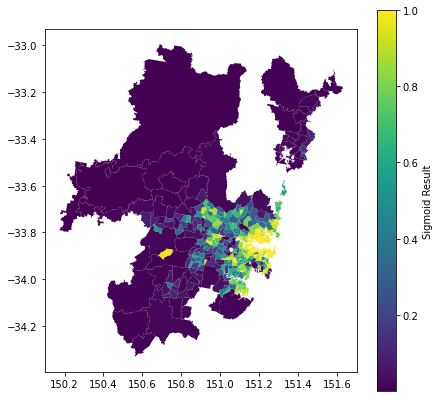

In [119]:
ax = task2.plot(column='sigmoid_result', figsize=(7, 7), cmap='viridis', legend=False)
plt.colorbar(ax.collections[0], ax=ax, orientation='vertical', label='Sigmoid Result')
plt.show()

#  Task 3

## POI

In [164]:
path_to_file = 'Task 3 Data/Points_Of_Interest_EPSG4326.json'

In [165]:
import geojson
with open(path_to_file) as f:
    gj = geojson.load(f)
# features = gj['features'][0]

In [166]:
df_poi = pd.json_normalize(gj['Points_Of_Interest']['features'],meta=['type', ['features', 'type'], ['features', 'geometry']])
print(df_poi.shape)
df_poi.head()

(143405, 21)


,type,geometry.type,geometry.coordinates,properties.topoid,properties.poigroup,properties.poitype,properties.poiname,properties.poilabel,properties.poilabeltype,properties.poialtlabel,...,properties.accesscontrol,properties.startdate,properties.enddate,properties.lastupdate,properties.msoid,properties.centroidid,properties.shapeuuid,properties.changetype,properties.processstate,properties.urbanity
0,Feature,Point,"[152.122022, -31.106163]",500000000,9,Mine - Underground,None,Mine - Underground,GENERIC,None,...,1,20210811075603,30000101000000,20210811075657,233046,None,729e2b57-0cd4-3f70-90fa-9dce09e34a8e,I,None,S
1,Feature,Point,"[152.298688, -31.021475]",500005504,3,Lookout,KUNDERANG LOOKOUT,KUNDERANG LOOKOUT,NAMED,None,...,1,20100927115312,30000101000000,20100927115312.535000,83091,None,d88a28a8-c572-3992-995f-d26a274aea18,I,None,S
2,Feature,Point,"[152.337856, -31.015759]",500005505,3,Lookout,FALLS LOOKOUT,FALLS LOOKOUT,NAMED,None,...,1,20100927115312,30000101000000,20100927115312.535000,83691,None,21b476d2-6519-3e28-8b19-1526fcb9652f,I,None,S
3,Feature,Point,"[152.341813, -31.018974]",500005507,3,Lookout,MCCOYS LOOKOUT,MCCOYS LOOKOUT,NAMED,None,...,1,20100927115312,30000101000000,20100927115312.535000,83380,None,016d69b2-6530-39e7-89a6-6e3054df55ac,I,None,S
4,Feature,Point,"[152.478825, -31.20754]",500012781,3,Picnic Area,WILSON RIVER PICNIC AREA,WILSON RIVER PICNIC AREA,NAMED,None,...,1,20201223091118,30000101000000,20201223091146.360000,231054,None,49ad26c8-609e-3aa0-b4ad-51459b43ab51,M,None,S


In [167]:
df_poi.describe()

,properties.topoid,properties.poigroup,properties.poisourcefeatureoid,properties.accesscontrol,properties.msoid
count,1.434050e+05,143405.000000,143405.000000,143405.0,143405.000000
mean,5.110120e+08,2.972958,58.432851,1.0,142297.717548
std,5.618819e+06,2.325082,49.029415,0.0,70086.125259
min,5.000000e+08,1.000000,1.000000,1.0,1.000000
25%,5.051353e+08,1.000000,13.000000,1.0,83978.000000
50%,5.130093e+08,3.000000,48.000000,1.0,155971.000000
75%,5.156241e+08,4.000000,84.000000,1.0,203160.000000
max,5.184452e+08,9.000000,166.000000,1.0,242107.000000


In [168]:
# replace column name to make it more standardized
df_poi.columns = df_poi.columns.str.replace('.','_')
df_poi.dtypes

type                              object
geometry_type                     object
geometry_coordinates              object
properties_topoid                  int64
properties_poigroup                int64
properties_poitype                object
properties_poiname                object
properties_poilabel               object
properties_poilabeltype           object
properties_poialtlabel            object
properties_poisourcefeatureoid     int64
properties_accesscontrol           int64
properties_startdate              object
properties_enddate                object
properties_lastupdate             object
properties_msoid                   int64
properties_centroidid             object
properties_shapeuuid              object
properties_changetype             object
properties_processstate           object
properties_urbanity               object
dtype: object

In [169]:
df_poi['type'].unique()

array(['Feature'], dtype=object)

In [119]:
df_poi['geometry_type'].unique()

array(['Point'], dtype=object)

In [121]:
len(df_poi['properties_topoid'].unique())
#  unique id

143405

In [201]:
df_poi['geometry_coordinates'].unique
# unique coordinates

<bound method Series.unique of 0         [152.122022, -31.106163]
1         [152.298688, -31.021475]
2         [152.337856, -31.015759]
3         [152.341813, -31.018974]
4          [152.478825, -31.20754]
                    ...           
143400    [151.109504, -33.938152]
143401    [151.110133, -33.938101]
143402    [151.108852, -33.938194]
143403    [151.108207, -33.938241]
143404    [151.100007, -33.939702]
Name: geometry_coordinates, Length: 143405, dtype: object>

In [223]:
# keep only useful columns
df_poi_clean = df_poi[['geometry_coordinates','properties_topoid','properties_poitype','properties_poiname']]

### Clean up the coordinates

In [224]:
df_poi_clean_geo = gpd.GeoDataFrame(df_poi_clean)

In [225]:
def create_point(coords):
    return Point(coords[0], coords[1])

# Apply the function to create Point geometries
df_poi_clean_geo['geometry_coordinates'] = df_poi_clean_geo['geometry_coordinates'].apply(create_point)


df_poi_clean_geo

,geometry_coordinates,properties_topoid,properties_poitype,properties_poiname
0,POINT (152.122022 -31.106163),500000000,Mine - Underground,None
1,POINT (152.298688 -31.021475),500005504,Lookout,KUNDERANG LOOKOUT
2,POINT (152.337856 -31.015759),500005505,Lookout,FALLS LOOKOUT
3,POINT (152.341813 -31.018974),500005507,Lookout,MCCOYS LOOKOUT
4,POINT (152.478825 -31.20754),500012781,Picnic Area,WILSON RIVER PICNIC AREA
...,...,...,...,...
143400,POINT (151.109504 -33.938152),518445230,Roadside Emergency Telephone,MEP3631E
143401,POINT (151.110133 -33.938101),518445231,Roadside Emergency Telephone,MEP3621E
143402,POINT (151.108852 -33.938194),518445232,Roadside Emergency Telephone,MEP3632E
143403,POINT (151.108207 -33.938241),518445233,Roadside Emergency Telephone,MEP3641E


### Load to SQL

In [226]:
# Convert Point geometries to WKT format
df_poi_clean_geo['geometry_coordinates'] = df_poi_clean_geo['geometry_coordinates'].apply(lambda x: x.wkt)

In [212]:
conn.execute('''
drop table if exists poi;
create table poi (
geometry_coordinates              GEOMETRY(POINT,4326) primary key,
properties_topoid                  int,
properties_poitype                varchar(100),
properties_poiname                varchar(100)
);             
''')
df_poi_clean_geo.to_sql('poi', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from poi")

,geometry_coordinates,properties_topoid,properties_poitype,properties_poiname
0,POINT (152.122022 -31.106163),500000000,Mine - Underground,None
1,POINT (152.298688 -31.021475),500005504,Lookout,KUNDERANG LOOKOUT
2,POINT (152.337856 -31.015759),500005505,Lookout,FALLS LOOKOUT
3,POINT (152.341813 -31.018974),500005507,Lookout,MCCOYS LOOKOUT
4,POINT (152.478825 -31.20754),500012781,Picnic Area,WILSON RIVER PICNIC AREA
...,...,...,...,...
143400,POINT (151.109504 -33.938152),518445230,Roadside Emergency Telephone,MEP3631E
143401,POINT (151.110133 -33.938101),518445231,Roadside Emergency Telephone,MEP3621E
143402,POINT (151.108852 -33.938194),518445232,Roadside Emergency Telephone,MEP3632E
143403,POINT (151.108207 -33.938241),518445233,Roadside Emergency Telephone,MEP3641E


## 2. Green

In [50]:
file_path = 'Task 3 Data/green_cleaned/green.shp'
df_green = gpd.read_file(file_path, crs="EPSG:4326")
print(df_green.shape)
df_green.head()

(12978, 4)


,ASSET_NAME,LAY_CLASS,weights,geometry
0,Crown Reserve 55 (Part),Undeveloped or Unspecified,0.00,"POLYGON ((150.49420 -33.72286, 150.49414 -33.7..."
1,Albert Sloss Reserve,Civic,1.00,"POLYGON ((151.21631 -33.87802, 151.21624 -33.8..."
2,Mount Kuring-Gai Park,Bushland,-0.25,"POLYGON ((151.13290 -33.66195, 151.13268 -33.6..."
3,Jardine Park,Sports,1.00,"POLYGON ((150.90518 -33.94474, 150.90528 -33.9..."
4,Bray Street Reserve,Parks and Gardens,0.75,"POLYGON ((151.05453 -33.80032, 151.05433 -33.8..."


In [105]:
#transform to multipolygon
# srid = 4326

# def create_wkt_element(geom, srid):
#     if geom.geom_type == 'Polygon':
#         geom = MultiPolygon([geom])
#     return WKTElement(geom.wkt, srid)

df_greenog = df_green.copy()  # creating a copy of the original for laterog = df_school.copy()  # creating a copy of the original for later
df_green['geom'] = df_green['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
df_green = df_green.drop(columns="geometry")  # deleting the old copy
df_green

,ASSET_NAME,LAY_CLASS,weights,geom
0,Crown Reserve 55 (Part),Undeveloped or Unspecified,0.00,MULTIPOLYGON (((150.494196589 -33.722858136999...
1,Albert Sloss Reserve,Civic,1.00,MULTIPOLYGON (((151.216310603 -33.878018344999...
2,Mount Kuring-Gai Park,Bushland,-0.25,MULTIPOLYGON (((151.1328978350001 -33.66194619...
3,Jardine Park,Sports,1.00,MULTIPOLYGON (((150.9051818360001 -33.94474217...
4,Bray Street Reserve,Parks and Gardens,0.75,MULTIPOLYGON (((151.05452536300004 -33.8003232...
...,...,...,...,...
12973,St Ives Bowling Club,Sports,1.00,MULTIPOLYGON (((151.1609315180001 -33.72650095...
12974,Pt. Reserve 57651,Bushland,-0.25,MULTIPOLYGON (((150.3896085120001 -33.50124063...
12975,Kurraba Reserve,OSL,0.00,MULTIPOLYGON (((151.22259802100007 -33.8444063...
12976,Thurlow St Reserve,Civic,1.00,MULTIPOLYGON (((151.05594684100004 -33.9509262...


In [51]:
df_green.describe()

,weights
count,12978.000000
mean,0.534096
std,0.446590
min,-0.250000
25%,0.000000
50%,0.750000
75%,0.750000
max,1.000000


In [81]:
df_green.dtypes

ASSET_NAME      object
LAY_CLASS       object
weights        float64
geometry      geometry
dtype: object

In [108]:
df_green.geom.unique

<bound method Series.unique of 0        MULTIPOLYGON (((150.494196589 -33.722858136999...
1        MULTIPOLYGON (((151.216310603 -33.878018344999...
2        MULTIPOLYGON (((151.1328978350001 -33.66194619...
3        MULTIPOLYGON (((150.9051818360001 -33.94474217...
4        MULTIPOLYGON (((151.05452536300004 -33.8003232...
                               ...                        
12973    MULTIPOLYGON (((151.1609315180001 -33.72650095...
12974    MULTIPOLYGON (((150.3896085120001 -33.50124063...
12975    MULTIPOLYGON (((151.22259802100007 -33.8444063...
12976    MULTIPOLYGON (((151.05594684100004 -33.9509262...
12977    MULTIPOLYGON (((150.7728518550001 -33.76625998...
Name: geom, Length: 12978, dtype: object>

### Load to SQL

In [109]:
conn.execute('''
drop table if exists task_3_green;
create table task_3_green (
   ASSET_NAME varchar(100),
   LAY_CLASS varchar(100),
   weights float,
   geom  geometry(Multipolygon,4326)
             );
''')
df_green.to_sql('task_3_green', conn, if_exists='replace', index=False, dtype={'geom': Geometry('Multipolygon', srid)})
query(conn, "select * from task_3_green")

,ASSET_NAME,LAY_CLASS,weights,geom
0,Crown Reserve 55 (Part),Undeveloped or Unspecified,0.00,0106000020E61000000100000001030000000100000009...
1,Albert Sloss Reserve,Civic,1.00,0106000020E6100000010000000103000000010000000B...
2,Mount Kuring-Gai Park,Bushland,-0.25,0106000020E61000000100000001030000000100000015...
3,Jardine Park,Sports,1.00,0106000020E61000000100000001030000000100000024...
4,Bray Street Reserve,Parks and Gardens,0.75,0106000020E61000000100000001030000000100000006...
...,...,...,...,...
12973,St Ives Bowling Club,Sports,1.00,0106000020E61000000100000001030000000100000009...
12974,Pt. Reserve 57651,Bushland,-0.25,0106000020E61000000100000001030000000100000006...
12975,Kurraba Reserve,OSL,0.00,0106000020E61000000100000001030000000200000026...
12976,Thurlow St Reserve,Civic,1.00,0106000020E61000000100000001030000000100000005...


## 3. School Data

### School Locations and Ranking

First step is to load in all the required Packages

#### Location Dataset

Next we need the list of schools (names) with locations attached. This includes all 3300 schools in NSW (Make sure the related CSV is in the same directory as this notebook). This is read in, its two coordinates columns converted into a single geometry column, and finally stripped back to just contain the necessary data.

In [8]:
Initial_data_path = 'Task 3 Data/Scraped_School_data/NSW_Schools.csv'
school_location_data = pd.read_csv(Initial_data_path)
latitudes = school_location_data['Latitude']
longitudes = school_location_data['Longitude']
school_location_data = gpd.GeoDataFrame(school_location_data, geometry=gpd.points_from_xy(longitudes, latitudes)) #Pairs together Longitude Latitude pairs and turns them into geometry points
school_location_data = school_location_data[['School Name','geometry']] # Keep only important columns
school_location_data.head()

,School Name,geometry
0,A.G.B.U. Alexander Primary School,POINT (151.18715 -33.67679)
1,Abbotsford Public School,POINT (151.13100 -33.85270)
2,Abbotsleigh,POINT (151.11100 -33.71990)
3,Abbotsleigh Junior School,POINT (151.11300 -33.71620)
4,Aberdeen Public School,POINT (150.88800 -32.16610)


### Scraping the Ranking Data (School Names)

Next we begin scraping the data containing the HSC 'results' of numerous schools in NSW.

In [9]:
basic_URL = "https://bettereducation.com.au/Results/Hsc.aspx" #This is where the data is coming from
try:
    webpage_source = requests.get(basic_URL).text
except:
    print('Error Occured: Request Failed')
try:
    content = BeautifulSoup(webpage_source, 'html5lib')
except:
        print('Error Occured: Parsing Failed')

This webpage contains a table with ~200 schools, where the data is contained within tags of a similar id. To efficiently extract these I created a function that takes in a number (Row Number) and returns the related id for that school's name.

In [10]:
def id_constructor(start='ctl00_ContentPlaceHolder1_GridView1_ctl',end='_HyperLinkSchool',number='0'):
    new_id = str(start) + str(number) + str(end)
    return new_id

Next we use this function to get the id's for all the rows of the table. This is where we go overboard, and create id's for up to 300 schools, as the exact number of rows in the table is somewhat confusing actually know. On the website you can view 299 schools, but the table says it only has 205.

In [11]:
ids = [] #This will be used each time we iterate over the table.
for i in range(300):
    ids.append(str(str(i).zfill(2))) # zfill is used to pad with 0s required by the tag.

name_ids = []
for i in ids:
    name_ids.append(id_constructor(number=i))

Now we come to actually extracting the names, and storing them in a list that will later be turned into a database column.

In [12]:
school_names_rankings = []
for code in name_ids:
    try:    # try loop is used in case we have got too many ids, and we try to access a row that doesn't exist.
        name = content.find('a', id=code).text
        school_names_rankings.append(name)
    except:
        continue

By checking the length I can check that I have extracted 205 school names, which is partially what is expected from this table. So long as this remains consistent, everything is fine.

In [13]:
len(school_names_rankings)

205

### Scraping the Ranking Data (%DAs)

Next step is to repeat the above process, only this time extracting the data on 'Percentage of exams sat that achieved a DA'. This will be our metric of school success. This begins by creating all the ids for each row of this column of data.

In [14]:
percentDA_ids = []
for i in ids:
    percentDA_ids.append(id_constructor(start='ctl00_ContentPlaceHolder1_GridView1_ctl', end='_lblPercent', number=i))

As before I have a list to store all the results that will later be turned into a column. Iterate over the each of the ids from before to get each entry.

In [15]:
school_percentageDA = []
for code in percentDA_ids:
    try:    # Once again using a try to account for the excess of ids.
        percent_DA = content.find('span', id=code).text
        school_percentageDA.append(percent_DA)
    except:
        continue

### Scraping the HSC Students Data

In addition to the %DA, the website contains information on the number of enrolled HSC students of each school mentioned. This is valuable in determining how 'Bustling' a school is, as more students strongly implies the school is more bustling.

In [16]:
hscStudents_ids = []
for i in ids:
    hscStudents_ids.append(id_constructor(end='_lblStudents', number=i))

Store all the Student Numbers in a list that will be added as a column, iterating over each of the ids made above.

In [17]:
school_HSCstudents = []
for code in hscStudents_ids:
    try:    # Once again using a try to account for the excess of ids.
        HSCstudents = content.find('span', id=code).text
        school_HSCstudents.append(HSCstudents)
    except:
        continue

### Scraping the number of Exams Sat

While the number of students is a good indicator of bustling, 'bustling' is better defined as full of activity, and what activity better than sitting tests. So this will be another good indicator of how 'bustling' the schools actually are.

In [18]:
testSat_ids = []
for i in ids:
    testSat_ids.append(id_constructor(end='_lblExamsSat', number=i))

Once again using the ids to extract each table entry.

In [19]:
school_testSat = []
for code in testSat_ids:
    try:    # Once again using a try to account for the excess of ids.
        testSat = content.find('span', id=code).text
        school_testSat.append(testSat)
    except:
        continue

### Matching Names

Testing for names that are duplicates by turning the list into a set (which removes duplicates). As the lengths are the same, we can assume there are no duplicates.

In [20]:
len(school_names_rankings), len(set(school_names_rankings))

(205, 205)

Attempting to see how many of the school names line up across datasets. Without any alterations, there are 154 that match, and 51 schools that don't match up. These will be the ones we have to identify manually.

In [21]:
matched_schools = list(set(school_names_rankings) & set(school_location_data['School Name']))
unmatched_schools = list(set(school_names_rankings) - set(school_location_data['School Name']))
len(matched_schools), len(unmatched_schools)

(154, 51)

In [25]:
unmatched_schools_df = pd.DataFrame(unmatched_schools)
unmatched_schools_df.to_csv('Task Data Output/Task 3 - Schools_to_be_renamed.csv')

In [29]:
unmatched_schools_correct_names = pd.read_csv('Task Data Output/Task 3 - Schools_to_be_renamed.csv')
unmatched_schools_correct_names = unmatched_schools_correct_names.drop(['Unnamed: 0'], axis=1) # Remove the extra 
unmatched_schools_correct_names

,0
0,"St John XXIII Catholic College,Stanhope Garden..."
1,"St Augustine's College,Brookvale,NSW,2100"
2,Oakhill College Castle Hill
3,Penrith Selective High School
4,St Patrick's Marist College (Dundas)
5,Canberra Grammar School
6,Smith's Hill High School
7,St Mary's Cathedral College (Sydney)
8,Broughton Anglican College (Menangle Park)
9,Parramatta Marist High School (Westmead)


A new file containing the incorrect names paired with the correct names was painfully put together, so as to ensure correct mapping, as any level of automation ended up resulting in some incorrections.

In [30]:
unmatched_schools_correct_names = pd.read_csv('Task 3 Data/Schools_with_new_names.csv')
unmatched_schools_correct_names = unmatched_schools_correct_names.drop(['Unnamed: 0'], axis=1) # Remove the extra 
incorrect_names = list(unmatched_schools_correct_names['Original Name'])
correct_names = list(unmatched_schools_correct_names['New Name'])

Go through each incorrect name in the original list and replace it with the correct one.

In [31]:
for i in range(len(incorrect_names)):
    index = school_names_rankings.index(incorrect_names[i])
    school_names_rankings[index] = correct_names[i]

We expect to have 203 schools as 2 schools could not be matched (Actual location ACT, not NSW).

In [32]:
len(set(school_names_rankings) & set(school_location_data['School Name']))

203

### Storing Data

Storing the data in a dataframe, which will soon be attached to the location GeoDataFrame.

In [33]:
school_ranking_data = {
    'school_name': school_names_rankings,
    'HSC_students': school_HSCstudents,
    'exams_sat': school_testSat,
    'school_achievement': school_percentageDA
}
school_ranking_data = pd.DataFrame(school_ranking_data)
school_ranking_data.head()

,school_name,HSC_students,exams_sat,school_achievement
0,North Sydney Boys High School,158,955,69.0%
1,James Ruse Agricultural High School,158,996,60.0%
2,Baulkham Hills High School,200,1210,55.8%
3,North Sydney Girls High School,153,909,54.7%
4,Reddam House,122,684,54.2%


### Combining Data

The next step is to actually combine the two datasets, we've been thorough in the previous step to ensure that they can be properly joined by the name columns.

In [70]:
school_complete_data = school_ranking_data.merge(
    right = school_location_data, 
    how = 'inner',
    left_on = 'school_name',
    right_on = 'School Name')
school_complete_data = school_complete_data.drop(['School Name'], axis=1) # Remove the duplicate column
school_complete_data = gpd.GeoDataFrame(school_complete_data) # Make the dataframe a Geodataframe
school_complete_data.set_geometry('geometry',inplace=True) # Make sure the correct column is the geometry column
school_complete_data.head()

,school_name,HSC_students,exams_sat,school_achievement,geometry
0,North Sydney Boys High School,158,955,69.0%,POINT (151.20700 -33.82960)
1,James Ruse Agricultural High School,158,996,60.0%,POINT (151.04300 -33.78060)
2,Baulkham Hills High School,200,1210,55.8%,POINT (150.99100 -33.75020)
3,North Sydney Girls High School,153,909,54.7%,POINT (151.20300 -33.83020)
4,Reddam House,122,684,54.2%,POINT (151.25300 -33.88930)


Finally with our complete data we can save it somewhere.

In [71]:
school_complete_data.to_file('Task Data Output/Task 3 - School_complete_data.shp')

<ipython-input-71-5911dbf290ec>:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  school_complete_data.to_file('Task Data Output/Task 3 - School_complete_data.shp')


To test whether it was correctly saved, we can load in the file and check the details.

In [99]:
school_complete_data2 = gpd.read_file('Task Data Output/Task 3 - School_complete_data.shp')
school_complete_data2

,school_nam,HSC_studen,exams_sat,school_ach,geometry
0,North Sydney Boys High School,158,955,69.0%,POINT (151.20700 -33.82960)
1,James Ruse Agricultural High School,158,996,60.0%,POINT (151.04300 -33.78060)
2,Baulkham Hills High School,200,1210,55.8%,POINT (150.99100 -33.75020)
3,North Sydney Girls High School,153,909,54.7%,POINT (151.20300 -33.83020)
4,Reddam House,122,684,54.2%,POINT (151.25300 -33.88930)
...,...,...,...,...,...
200,Broughton Anglican College,96,531,5.8%,POINT (150.76800 -34.09970)
201,St Columba's Catholic College,120,659,5.8%,POINT (150.58800 -33.67320)
202,Cedars Christian College,45,228,5.7%,POINT (150.82900 -34.45550)
203,St Philip's Christian College - Port Stephens,44,232,5.6%,POINT (152.11000 -32.73830)


In [120]:
#transform to multipolygon
srid = 4326

def create_wkt_element(geom, srid):
    if geom.geom_type == 'Polygon':
        geom = MultiPolygon([geom])
    return WKTElement(geom.wkt, srid)

school_complete_data2og = school_complete_data2.copy()  # creating a copy of the original for laterog = df_school.copy()  # creating a copy of the original for later
school_complete_data2['geom'] = school_complete_data2['geometry'].apply(lambda x: create_wkt_element(geom=x,srid=srid))  # applying the function
school_complete_data2 = school_complete_data2.drop(columns="geometry")  # deleting the old copy
school_complete_data2

,school_nam,HSC_studen,exams_sat,school_ach,geom
0,North Sydney Boys High School,158,955,69.0%,POINT (151.207 -33.8296)
1,James Ruse Agricultural High School,158,996,60.0%,POINT (151.043 -33.7806)
2,Baulkham Hills High School,200,1210,55.8%,POINT (150.991 -33.7502)
3,North Sydney Girls High School,153,909,54.7%,POINT (151.203 -33.8302)
4,Reddam House,122,684,54.2%,POINT (151.253 -33.8893)
...,...,...,...,...,...
200,Broughton Anglican College,96,531,5.8%,POINT (150.768 -34.0997)
201,St Columba's Catholic College,120,659,5.8%,POINT (150.588 -33.6732)
202,Cedars Christian College,45,228,5.7%,POINT (150.829 -34.4555)
203,St Philip's Christian College - Port Stephens,44,232,5.6%,POINT (152.11 -32.7383)


In [96]:
# # reverse the longtitude and latitude to make sure the coordinates are correct
# school_complete_data2['geometry'] = gpd.GeoSeries(school_complete_data2['geometry']).map(lambda polygon: shapely.ops.transform(lambda x, y: (y, x), polygon))


In [100]:
school_complete_data2.head()

,school_nam,HSC_studen,exams_sat,school_ach,geometry
0,North Sydney Boys High School,158,955,69.0%,POINT (151.20700 -33.82960)
1,James Ruse Agricultural High School,158,996,60.0%,POINT (151.04300 -33.78060)
2,Baulkham Hills High School,200,1210,55.8%,POINT (150.99100 -33.75020)
3,North Sydney Girls High School,153,909,54.7%,POINT (151.20300 -33.83020)
4,Reddam House,122,684,54.2%,POINT (151.25300 -33.88930)


In [101]:
school_complete_data2.dtypes

school_nam      object
HSC_studen      object
exams_sat       object
school_ach      object
geometry      geometry
dtype: object

### Load To SQL

In [127]:
conn.execute('''
drop table if exists task_3_school_data;
create table task_3_school_data (
   school_nam varchar(100),
   HSC_studen int,
   exams_sat int,
   school_ach float,
   geom  GEOMETRY(POINT,4326)
);'''
)
school_complete_data2.to_sql('task_3_school_data', conn, if_exists='replace', index=False, dtype={'geom': Geometry('POINT', srid)})
query(conn, "select * from task_3_school_data")

,school_nam,HSC_studen,exams_sat,school_ach,geom
0,North Sydney Boys High School,158,955,69.0%,0101000020E6100000B4C876BE9FE662407C61325530EA...
1,James Ruse Agricultural High School,158,996,60.0%,0101000020E61000004C37894160E16240F9A067B3EAE3...
2,Baulkham Hills High School,200,1210,55.8%,0101000020E6100000C1CAA145B6DF6240C7BAB88D06E0...
3,North Sydney Girls High School,153,909,54.7%,0101000020E6100000D122DBF97EE66240D1915CFE43EA...
4,Reddam House,122,684,54.2%,0101000020E61000006ABC749318E86240992A1895D4F1...
...,...,...,...,...,...
200,Broughton Anglican College,96,531,5.8%,0101000020E61000007F6ABC7493D86240A2B437F8C20C...
201,St Columba's Catholic College,120,659,5.8%,0101000020E6100000894160E5D0D2624067D5E76A2BD6...
202,Cedars Christian College,45,228,5.7%,0101000020E61000004A0C022B87DA6240FCA9F1D24D3A...
203,St Philip's Christian College - Port Stephens,44,232,5.6%,0101000020E6100000EC51B81E850363408351499D805E...


## 4. Join in all tables

In [214]:
query_conntent = '''
drop table if exists combined_task3;
create table combined_task3 as
with poi as(
select c.*
,sum(case  when properties_poitype in (
	'Park','Picnic Area','Sports Field','Ambulance Station','Academy','Tourist Information Centre','University','Zoo'
	,'Technical College','Integrated Health Service','','Art Gallery'
	,'Library','Preschool','Embassy','Child Care Centre','Cycling Track','Athletics Track','Psychiatric Hospital'
	,'Sports Court','Shopping Centre','Post Office','Museum','Airport','General Hospital','TAFE College',
	'Sports Centre','Court House','Outdoor Theatre','Special School','Community Medical Centre') then 1
	when  properties_poitype in ('Place of Worship','Dog Track','Tourist Park / Home Village','Retirement Village','Golf Course'
	  ,'Local Government Chambers','Power Station - Hydro','Community Facility','Education Facility','Lighthouse'
	  ,'Showground','Parking Area','Tourist Attraction','Fire Station','Power Station - Fuel Driven','Marina','Police Station'
	  ,'Motor Racing Track','Swimming Pool','Community Home') then 0.5
	when  properties_poitype in ('Camping Ground','Lookout') then 0.25
									   else 0
	 end) as poi_weights
from combined c
left join poi p on st_contains(c.geom,ST_SetSRID(geometry_coordinates::geometry, 4326))
-- where "GCC_NAME21" = 'Greater Sydney'
group by 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
	)
	,green as (
		select p.*, sum(g.weights) as green_weights
		from poi p
	left join task_3_green g on st_intersects(p.geom,g.geom)
	group by 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
	)
	,school as (
		select cast(exams_sat as int) as exams_sat
					,cast("HSC_studen" as int) as hsc_student
					,cast(cast(substr(school_ach,1,length(school_ach)-1) as float)/100 as decimal(20,2)) as school_achievement
					,geom
					from task_3_school_data
	)
	select 
	g.*
	,sum(exams_sat) as exams_sat
	,sum(hsc_student) as hsc_student
	,max(school_achievement) as school_achievement
	from green g
	left join school s on st_contains(g.geom,s.geom) 
	group by 1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
    '''
query(conn,query_conntent)

Error encountered: 
This result object does not return rows. It has been closed automatically.


""


In [133]:
df_task3 = query(conn, "select * from combined_task3")
df_task3

,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,GCC_NAME21,geom,area_size,num_polls,num_schools,...,total_businesses,total_turnover,num_0_19_people,young_perc,total_people,poi_weights,green_weights,exams_sat,hsc_student,school_achievement
0,101021007,Braidwood,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E6100000010000000103000000010000005D...,339396.981825,3,16,...,725.0,360450.0,NaN,NaN,NaN,45.00,NaN,NaN,NaN,NaN
1,101021008,Karabar,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E6100000010000000103000000010000002C...,692.573630,1,7,...,418.0,205700.0,NaN,NaN,NaN,40.00,NaN,NaN,NaN,NaN
2,101021009,Queanbeyan,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E61000000100000001030000000100000050...,472.213420,7,5,...,865.0,711525.0,NaN,NaN,NaN,58.50,NaN,NaN,NaN,NaN
3,101021010,Queanbeyan - East,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E610000001000000010300000001000000FE...,1289.504434,1,4,...,663.0,903775.0,NaN,NaN,NaN,37.00,NaN,NaN,NaN,NaN
4,101021012,Queanbeyan West - Jerrabomberra,Queanbeyan,Capital Region,New South Wales,Rest of NSW,0106000020E610000001000000010300000001000000E1...,1356.377525,1,7,...,898.0,917900.0,NaN,NaN,NaN,44.25,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,801101145,Molonglo - East,Molonglo,Australian Capital Territory,Australian Capital Territory,Australian Capital Territory,0106000020E61000000100000001030000000100000071...,726.515738,0,0,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2239,801101146,Whitlam,Molonglo,Australian Capital Territory,Australian Capital Territory,Australian Capital Territory,0106000020E61000000100000001030000000100000031...,322.870833,0,0,...,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2240,801111140,ACT - South West,Uriarra - Namadgi,Australian Capital Territory,Australian Capital Territory,Australian Capital Territory,0106000020E6100000010000000103000000010000000C...,41348.651866,0,2,...,NaN,NaN,NaN,NaN,NaN,44.25,NaN,NaN,NaN,NaN
2241,801111141,Namadgi,Uriarra - Namadgi,Australian Capital Territory,Australian Capital Territory,Australian Capital Territory,0106000020E6100000010000000103000000010000004B...,119674.585266,0,10,...,NaN,NaN,NaN,NaN,NaN,19.25,NaN,NaN,NaN,NaN


In [132]:
df_task3.to_csv('Task Data Output/Task 3 Combined Table No Filters.csv')

In [134]:
df_task3.dtypes

SA2_CODE21              int64
SA2_NAME21             object
SA3_NAME21             object
SA4_NAME21             object
STE_NAME21             object
GCC_NAME21             object
geom                   object
area_size             float64
num_polls               int64
num_schools             int64
num_stops               int64
num_earners           float64
median_age            float64
median_income         float64
mean_income           float64
total_businesses      float64
total_turnover        float64
num_0_19_people       float64
young_perc            float64
total_people          float64
poi_weights           float64
green_weights         float64
exams_sat             float64
hsc_student           float64
school_achievement    float64
dtype: object

### Create Z Scores

In [145]:
conn.execute(
	'''
	drop table if exists combined_z_score_task3;
    create table combined_z_score_task3 as

    with stats as (
    select avg(num_earners/area_size) as earners_avg
    ,stddev(num_earners/area_size) as earners_stdev
    ,avg(median_age) as age_avg
    ,stddev(median_age) as age_stdev
    ,avg(median_income) as income_avg
    ,stddev(median_income) as income_stdev
    ,avg(total_businesses/area_size) as num_business_avg
    ,stddev(total_businesses/area_size) as num_business_stdev
    ,avg(total_turnover/area_size) as turnover_avg
    ,stddev(total_turnover/area_size) as turnover_stdev
    ,avg(num_0_19_people/area_size) as young_num_avg
    ,stddev(num_0_19_people/area_size) as young_num_stdev
    ,avg(Young_perc) as young_perc_avg
    ,stddev(Young_perc) as young_perc_stdev
    ,avg(num_polls/area_size) as polls_avg
    ,stddev(num_polls/area_size) as polls_stdev
    ,avg(case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people*1000 end) as schools_avg
    ,stddev(case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people*1000 end) as schools_stdev
    ,avg(num_stops/area_size) as stops_avg
    ,stddev(num_stops/area_size) as stops_stdev
    ,avg(poi_weights/area_size) as poi_weights_avg
    ,stddev(poi_weights/area_size) as poi_weights_stdev
    ,avg(green_weights/area_size) as green_weights_avg
    ,stddev(green_weights/area_size) as green_weights_stdev
    ,avg(exams_sat) as exams_sat_avg
    ,stddev(exams_sat) as exams_sat_stdev
    ,avg(hsc_student) as hsc_student_avg
    ,stddev(hsc_student) as hsc_student_stdev
    ,avg(school_achievement) as school_achievement_avg
    ,stddev(school_achievement) as school_achievement_stdev

    from combined_task3
    where total_people >= 100
    and "GCC_NAME21" = 'Greater Sydney'
    )
    select "SA2_CODE21","SA2_NAME21","SA3_NAME21","SA4_NAME21","STE_NAME21"
    , (num_earners/area_size - earners_avg)/earners_stdev as earners_zscore
    , (median_age - age_avg)/age_stdev as age_zscore
    , (median_income - income_avg)/income_stdev as income_zscore
    , (total_businesses/area_size - num_business_avg)/num_business_stdev as business_zscore
    , (total_turnover/area_size - turnover_avg)/turnover_stdev as turnover_zscore
    , (num_0_19_people/area_size - young_num_avg)/young_num_stdev as yound_population_zscore
    , (young_perc - young_perc_avg)/young_perc_stdev as young_perc_zscore
    , (num_polls/area_size - polls_avg)/polls_stdev as polls_zscore
    , (case when num_0_19_people = 0 then 0 else num_schools/num_0_19_people*1000 end - schools_avg)/schools_stdev as schools_zscore
    , (num_stops/area_size - stops_avg)/stops_stdev as stops_zscore
    , (poi_weights/area_size - poi_weights_avg)/poi_weights_stdev as poi_weights_score
    , (green_weights/area_size - green_weights_avg)/green_weights_stdev as green_weights_score
    , (exams_sat - exams_sat_avg)/exams_sat_stdev as exams_sat_score
    , (hsc_student - hsc_student_avg)/hsc_student_stdev as hsc_student_score
    , (school_achievement - school_achievement_avg)/school_achievement_stdev as school_achievement_score
    , geom
    from combined_task3
		join stats s on 1=1
    where total_people >=100
		and "GCC_NAME21" = 'Greater Sydney'
    ''')
df_combined_z_score_task3 = query(conn, "select * from combined_z_score_task3")
df_combined_z_score_task3.head()

,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,earners_zscore,age_zscore,income_zscore,business_zscore,turnover_zscore,...,young_perc_zscore,polls_zscore,schools_zscore,stops_zscore,poi_weights_score,green_weights_score,exams_sat_score,hsc_student_score,school_achievement_score,geom
0,102011028,Avoca Beach - Copacabana,Gosford,Central Coast,New South Wales,-0.635775,1.277611,-0.406611,-0.453760,-0.386818,...,0.695857,-0.374595,-0.125352,-0.418669,-0.390148,NaN,NaN,NaN,NaN,0106000020E6100000010000000103000000010000005E...
1,102011029,Box Head - MacMasters Beach,Gosford,Central Coast,New South Wales,-0.912149,1.720101,-0.699085,-0.600869,-0.463550,...,-0.245152,-0.527438,-0.125346,-1.310781,-1.051276,NaN,NaN,NaN,NaN,0106000020E61000000100000001030000000100000010...
2,102011031,Erina - Green Point,Gosford,Central Coast,New South Wales,-0.896330,1.498856,-0.701136,-0.563458,-0.410831,...,-0.359660,-0.456464,-0.121537,-1.191704,-1.045226,NaN,-0.559314,-0.590458,0.312008,0106000020E61000000100000001030000000100000041...
3,102011032,Gosford - Springfield,Gosford,Central Coast,New South Wales,-0.648659,-0.049858,-0.471202,-0.421976,-0.286451,...,-0.555156,-0.310931,-0.124768,-0.331420,-0.336662,NaN,-0.137588,-0.170908,0.090766,0106000020E6100000010000000103000000010000007E...
4,102011033,Kariong,Gosford,Central Coast,New South Wales,-0.778234,0.171387,-0.110595,-0.581425,-0.448625,...,1.053848,-0.417558,-0.126598,-1.233473,-0.835237,NaN,NaN,NaN,NaN,0106000020E6100000010000000103000000010000000F...


In [146]:
df_combined_z_score_task3.to_csv('Task Data Output/Task 3 - Z Score.csv')

In [241]:
from shapely import wkt
df_poi_clean_geo['geometry'] = df_poi_clean_geo['geometry_coordinates'].apply(wkt.loads)

### Correlations

In [239]:
df_combined_z_score_task3.select_dtypes(include=['float', 'integer'])

,SA2_CODE21,earners_zscore,age_zscore,income_zscore,business_zscore,turnover_zscore,yound_population_zscore,young_perc_zscore,polls_zscore,schools_zscore,stops_zscore,poi_weights_score,green_weights_score,exams_sat_score,hsc_student_score,school_achievement_score
0,102011028,-0.635775,1.277611,-0.406611,-0.453760,-0.386818,-0.813304,0.695857,-0.374595,-0.125352,-0.418669,-0.390148,NaN,NaN,NaN,NaN
1,102011029,-0.912149,1.720101,-0.699085,-0.600869,-0.463550,-1.398589,-0.245152,-0.527438,-0.125346,-1.310781,-1.051276,NaN,NaN,NaN,NaN
2,102011031,-0.896330,1.498856,-0.701136,-0.563458,-0.410831,-1.357095,-0.359660,-0.456464,-0.121537,-1.191704,-1.045226,NaN,-0.559314,-0.590458,0.312008
3,102011032,-0.648659,-0.049858,-0.471202,-0.421976,-0.286451,-0.978572,-0.555156,-0.310931,-0.124768,-0.331420,-0.336662,NaN,-0.137588,-0.170908,0.090766
4,102011033,-0.778234,0.171387,-0.110595,-0.581425,-0.448625,-1.024291,1.053848,-0.417558,-0.126598,-1.233473,-0.835237,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,128021537,-1.019728,-0.934838,-2.092206,-0.649768,-0.488635,-1.576739,3.332435,-0.565788,1.180126,-1.755332,-1.346352,-1.026063,NaN,NaN,NaN
352,128021538,-0.093082,-0.049858,0.513778,-0.203015,-0.079139,-0.068874,-0.346925,-0.092704,-0.124552,-0.058791,0.125527,0.638411,0.879367,0.874413,-0.720454
353,128021607,-0.428480,0.392632,0.397739,-0.457680,-0.378408,-0.260826,0.903517,-0.087867,-0.126700,-0.090678,-0.111334,-0.117034,-0.674561,-0.725568,-0.351718
354,128021608,-0.424615,0.835122,0.341071,-0.471187,-0.411201,-0.335111,0.699325,-0.247691,-0.123021,0.778767,-0.318298,-0.377596,NaN,NaN,NaN


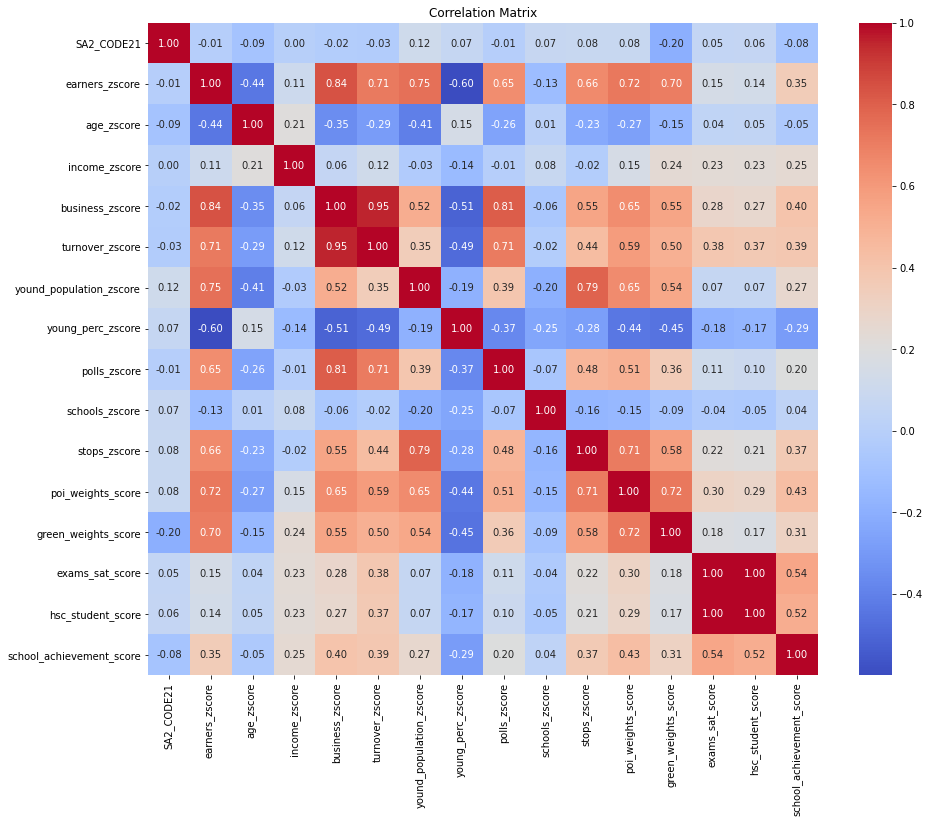

In [243]:
# Keep only columns with float and integer datatype
numeric_columns = df_combined_z_score_task3.select_dtypes(include=['float', 'integer'])

# calculate correlations
correlation_matrix = numeric_columns.corr()

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### heatmap summary:

From the heatmap, we see a strong correlation between earners with business, turnover, young population, young percentage, polls, stops, poi (Point of Interest) and Greens score. in Task 4, it is a potential application for machine learning by predicting number of earners using other informations.

<Axes: >

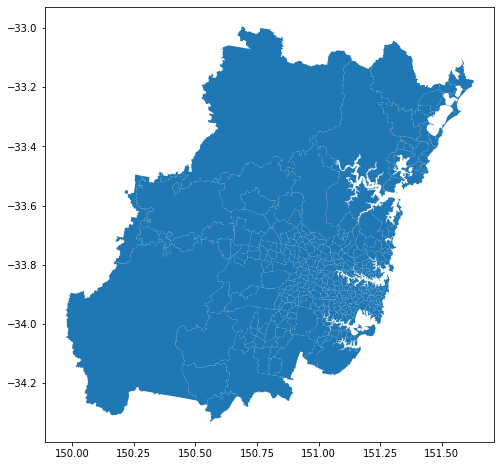

In [245]:
# Create figure/axes

fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot base map

df_sa2[df_sa2['GCC_NAME21'] == 'Greater Sydney'].plot(ax=ax1)


# Task 4 - 1. Ranks

In [246]:
conn.execute("""
drop table if exists task_4_ranks;
create table task_4_ranks as
select *
,case when area_size is null then null else rank() over(order by area_size desc) end as area_size_rank
,case when num_polls is null then null else rank() over(order by num_polls desc) end as num_polls_rank
,case when num_schools is null then null else rank() over(order by num_schools desc) end as num_schools_rank
,case when num_stops is null then null else rank() over(order by num_stops desc) end as num_stops_rank
,case when num_earners is null then null else rank() over(order by num_earners desc) end as num_earners_rank
,case when median_age is null then null else rank() over(order by median_age desc) end as median_age_rank
,case when median_income is null then null else rank() over(order by median_income desc) end as median_income_rank
,case when mean_income is null then null else rank() over(order by mean_income desc) end as mean_income_rank
,case when total_businesses is null then null else rank() over(order by total_businesses desc) end as total_businesses_rank
,case when total_turnover is null then null else rank() over(order by total_turnover desc) end as total_turnover_rank
,case when num_0_19_people is null then null else rank() over(order by num_0_19_people desc) end as num_0_19_people_rank
,case when young_perc is null then null else rank() over(order by young_perc desc) end as young_perc_rank
,case when total_people is null then null else rank() over(order by total_people desc) end as total_people_rank
,case when poi_weights is null then null else rank() over(order by poi_weights desc) end as poi_weights_rank
,case when green_weights is null then null else rank() over(order by green_weights desc) end as green_weights_rank
,case when exams_sat is null then null else rank() over(order by exams_sat desc) end as exams_sat_rank
,case when hsc_student is null then null else rank() over(order by hsc_student desc) end as hsc_student_rank
,case when school_achievement is null then null else rank() over(order by school_achievement desc) end as school_achievement_rank
from combined_task3
where total_people >=100
""")
df_task_4_rank = query(conn, "select * from task_4_ranks")
print(df_task_4_rank.shape)
df_task_4_rank.head()

(356, 43)


,SA2_CODE21,SA2_NAME21,SA3_NAME21,SA4_NAME21,STE_NAME21,GCC_NAME21,geom,area_size,num_polls,num_schools,...,total_businesses_rank,total_turnover_rank,num_0_19_people_rank,young_perc_rank,total_people_rank,poi_weights_rank,green_weights_rank,exams_sat_rank,hsc_student_rank,school_achievement_rank
0,124021456,Blue Mountains - South,Blue Mountains - South,Sydney - Outer West and Blue Mountains,New South Wales,Greater Sydney,0106000020E6100000010000000103000000010000004A...,239738.165566,0,35,...,356,355,354,354,356,155,354.0,NaN,NaN,NaN
1,115031299,Bilpin - Colo - St Albans,Hawkesbury,Sydney - Baulkham Hills and Hawkesbury,New South Wales,Greater Sydney,0106000020E610000001000000010300000001000000C3...,209053.927672,3,14,...,345,348,343,259,344,143,343.0,NaN,NaN,NaN
2,124011451,Blue Mountains - North,Blue Mountains,Sydney - Outer West and Blue Mountains,New South Wales,Greater Sydney,0106000020E61000000100000001030000000100000005...,57802.231432,0,20,...,354,354,354,354,354,297,356.0,NaN,NaN,NaN
3,115021297,Dural - Kenthurst - Wisemans Ferry,Dural - Wisemans Ferry,Sydney - Baulkham Hills and Hawkesbury,New South Wales,Greater Sydney,0106000020E6100000010000000103000000010000009C...,36651.117048,9,34,...,8,17,39,149,25,1,228.0,275.0,275.0,269.0
4,102021049,Jilliby - Yarramalong,Wyong,Central Coast,New South Wales,Greater Sydney,0106000020E610000001000000010300000001000000A8...,33522.159438,3,16,...,341,338,339,138,342,330,NaN,NaN,NaN,NaN


In [248]:
df_task_4_rank[['SA2_CODE21','SA2_NAME21','geom','total_businesses','num_stops','num_polls','num_schools','total_businesses_rank','num_stops_rank','num_polls_rank','num_schools_rank']]

,SA2_CODE21,SA2_NAME21,geom,total_businesses,num_stops,num_polls,num_schools,total_businesses_rank,num_stops_rank,num_polls_rank,num_schools_rank
0,124021456,Blue Mountains - South,0106000020E6100000010000000103000000010000004A...,0.0,2,0,35,356,356,340,1
1,115031299,Bilpin - Colo - St Albans,0106000020E610000001000000010300000001000000C3...,336.0,36,3,14,345,342,188,90
2,124011451,Blue Mountains - North,0106000020E61000000100000001030000000100000005...,6.0,4,0,20,354,355,340,10
3,115021297,Dural - Kenthurst - Wisemans Ferry,0106000020E6100000010000000103000000010000009C...,3804.0,697,9,34,8,1,8,2
4,102021049,Jilliby - Yarramalong,0106000020E610000001000000010300000001000000A8...,409.0,232,3,16,341,58,188,56
...,...,...,...,...,...,...,...,...,...,...,...
351,117031329,Darlinghurst,0106000020E610000001000000010300000001000000A8...,2354.0,56,7,10,54,318,21,201
352,117031648,Zetland,0106000020E61000000100000001030000000100000055...,1316.0,31,1,7,180,345,302,297
353,119041671,Wolli Creek,0106000020E61000000100000001030000000100000095...,861.0,12,0,10,280,352,340,201
354,117031646,Ultimo,0106000020E61000000100000001030000000100000079...,1785.0,24,1,7,113,347,302,297


In [263]:
weights = {
    'total_businesses': 0.4,
    'num_stops': 0.3,
    'num_polls': 0.1,
    'num_schools': 0.5
}

# Data transformation (logarithmic, to handle positive skew)
for col in ['total_businesses_rank', 'num_stops_rank', 'num_polls_rank', 'num_schools_rank']:
    df_task_4_rank[col + '_log'] = np.log1p(df_task_4_rank[col])

# Standardization (z-score normalization)
for col in ['total_businesses_rank_log', 'num_stops_rank_log', 'num_polls_rank_log', 'num_schools_rank_log']:
    df_task_4_rank[col + '_z'] = (df_task_4_rank[col] - df_task_4_rank[col].mean()) / df_task_4_rank[col].std()

# Calculate weighted score
df_task_4_rank['bustling_score'] = (
    df_task_4_rank['total_businesses_rank_log_z'] * weights['total_businesses'] +
    df_task_4_rank['num_stops_rank_log_z'] * weights['num_stops'] +
    df_task_4_rank['num_polls_rank_log_z'] * weights['num_polls'] +
    df_task_4_rank['num_schools_rank_log_z'] * weights['num_schools']
)

# Normalize bustling score to 0-100 scale
df_task_4_rank['normalized_bustling_score'] = (df_task_4_rank['bustling_score'] - df_task_4_rank['bustling_score'].min()) / (df_task_4_rank['bustling_score'].max() - df_task_4_rank['bustling_score'].min())



In [264]:
df_task_4_rank['normalized_bustling_score'].describe()

count    356.000000
mean       0.777381
std        0.153415
min        0.000000
25%        0.694769
50%        0.803673
75%        0.894792
max        1.000000
Name: normalized_bustling_score, dtype: float64

In [251]:
df_task2 = gpd.read_postgis('''select "SA2_CODE21", sigmoid_result,geom from task_2_result''', conn, crs=4326)
df_task2.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   SA2_CODE21      356 non-null    int64   
 1   sigmoid_result  355 non-null    float64 
 2   geom            356 non-null    geometry
dtypes: float64(1), geometry(1), int64(1)
memory usage: 8.5 KB


In [269]:
df_task2['sigmoid_result'].describe()

count    355.000000
mean       0.455548
std        0.373206
min        0.000026
25%        0.067017
50%        0.413568
75%        0.840829
max        1.000000
Name: sigmoid_result, dtype: float64

In [265]:
# try:
#     df_task_4_rank = df_task_4_rank.reset_index()
#     df_task2 = df_task2.reset_index()

# Performing the join using merge()
result_df = pd.merge(df_task_4_rank[['SA2_NAME21', 'SA2_CODE21', 'geom', 'normalized_bustling_score']],
                     df_task2[['SA2_CODE21', 'sigmoid_result']],
                     on='SA2_CODE21', 
                     suffixes=('_task4', '_task2')
                     )

In [266]:
result_df

,SA2_NAME21,SA2_CODE21,geom,normalized_bustling_score,sigmoid_result
0,Blue Mountains - South,124021456,0106000020E6100000010000000103000000010000004A...,0.566606,NaN
1,Bilpin - Colo - St Albans,115031299,0106000020E610000001000000010300000001000000C3...,0.878373,0.002865
2,Blue Mountains - North,124011451,0106000020E61000000100000001030000000100000005...,0.711667,0.000026
3,Dural - Kenthurst - Wisemans Ferry,115021297,0106000020E6100000010000000103000000010000009C...,0.000000,0.014440
4,Jilliby - Yarramalong,102021049,0106000020E610000001000000010300000001000000A8...,0.743429,0.007266
...,...,...,...,...,...
351,Darlinghurst,117031329,0106000020E610000001000000010300000001000000A8...,0.775111,1.000000
352,Zetland,117031648,0106000020E61000000100000001030000000100000055...,0.941890,0.998367
353,Wolli Creek,119041671,0106000020E61000000100000001030000000100000095...,0.943127,0.913403
354,Ultimo,117031646,0106000020E61000000100000001030000000100000079...,0.909213,0.999932


## Summary:
From range: ranking score has higher averages, median and standard deviations compared to sigmoid results, some of the low bustling areas could have very high scores compared to sigmoid results due to the ranking did not show the difference of bustling as well as the zscores.